In [1]:
%cd ..

/home/dmoreno/pipeline_v4_final/pipeline/training/stamp_classifier/data_acquisition/rubin


In [2]:
import pandas as pd
import glob

In [3]:
path_stamps = glob.glob('simulated_data/fakes/*.npy')
path_stamps

['simulated_data/fakes/611256378312376542_z_2024120800360_8_592913913020940296_z_2024111700354_4_0.33.npy',
 'simulated_data/fakes/609780833707896898_g_2024112900266_0_650018217640591465_g_2024112600116_4_0.88.npy',
 'simulated_data/fakes/611255691117605475_r_2024113000163_3_614437609048899879_r_2024112600305_1_0.74.npy',
 'simulated_data/fakes/611255622398132035_i_2024120300157_8_648363383921311853_i_2024112300236_6_0.90.npy',
 'simulated_data/fakes/609788117972430021_i_2024111900089_8_650018148921114792_i_2024112600128_5_0.57.npy',
 'simulated_data/fakes/611254454167020410_u_2024113000173_4_614437609048899610_u_2024120100460_7_0.40.npy',
 'simulated_data/fakes/611254454167020410_g_2024113000170_7_648366201419858478_g_2024120700172_2_0.88.npy',
 'simulated_data/fakes/609788942606153550_u_2024113000173_5_609782139377943544_u_2024113000174_7_0.83.npy',
 'simulated_data/fakes/611256447031856188_r_2024110800306_5_609782139377942804_r_2024113000163_8_0.62.npy',
 'simulated_data/fakes/61125

In [4]:
def parse_filename(filepath):
    """
    Extrae los metadatos del nombre de archivo según la convención del README.
    Devuelve un diccionario con los metadatos.
    """
    try:
        # 1. Obtiene solo el nombre del archivo, sin la ruta ni la extensión.
        # e.g., '.../file.npy' -> 'file'
        base_name = os.path.splitext(os.path.basename(filepath))[0]
        
        # 2. Divide el nombre del archivo por el guion bajo '_'
        parts = base_name.split('_')
        
        # 3. Asigna cada parte a su campo correspondiente, convirtiendo a número si es necesario.
        metadata = {
            'gal_objectId': parts[0],
            'gal_band': parts[1],
            'gal_visit': parts[2],
            'gal_detector': int(parts[3]),
            'diff_sourceId': parts[4],
            'diff_band': parts[5],
            'diff_visit': parts[6],
            'diff_detector': int(parts[7]),
            'SN_ellip_dist': float(parts[8]),
        }
        return metadata
    except (IndexError, ValueError) as e:
        print(f"ADVERTENCIA: No se pudo parsear el nombre del archivo: {filepath}. Error: {e}")
        return None

In [5]:
# 1. Cargar los DataFrames de metadatos
# Usa io.StringIO para leer el string como si fuera un archivo
# En tu código real, reemplazarías esto por: pd.read_csv('simulated_data/df_gal.csv')
df_diff_meta = pd.read_csv('simulated_data/fakes/df_diff.csv')
df_gal_meta = pd.read_csv('simulated_data/fakes/df_gal.csv')

# Renombrar columnas en los metadatos para evitar conflictos al unir
# Por ejemplo, 'ra', 'dec', 'band' existen en ambos archivos.
df_gal_meta.rename(columns={'ra': 'gal_ra', 'dec': 'gal_dec'}, inplace=True)
df_diff_meta.rename(columns={'ra': 'diff_ra', 'dec': 'diff_dec', 
                             'band': 'diff_band', 'visit': 'diff_visit', 
                             'detector':'diff_detector'}, inplace=True)

In [6]:
df_gal_meta

,Unnamed: 0.1,Unnamed: 0,objectId,band,visit,detector,psfFlux,psfFluxErr,psfFlux_flag,expMidptMJD,...,footprintArea,ccdVisitId,magLim,seeing,skyBg,skyNoise,zeroPoint,filename,has_file,confirmed
0,0,17,609788942606161287,i,2024110800297,3,511741.000,738.701,False,60623.303613,...,44694,1145019902211,23.7438,1.246038,1799.200,43.7858,31.8222,609788942606161287_i_2024110800297_3.fits,True,True
1,1,128,609788942606161287,y,2024111900097,8,793109.000,2379.690,False,60634.064805,...,44694,1145112125704,21.8621,1.182162,3518.250,60.8301,30.3207,609788942606161287_y_2024111900097_8.fits,True,True
2,2,16,609788942606161287,r,2024111900084,7,425013.000,599.514,False,60634.055509,...,44694,1145112122375,23.9403,1.555586,1044.330,33.3829,31.9865,609788942606161287_r_2024111900084_7.fits,True,True
3,3,57,609788942606161287,g,2024113000167,8,212924.000,429.999,False,60645.117400,...,44694,1145204418312,24.2894,1.714515,428.206,24.7000,32.0058,609788942606161287_g_2024113000167_8.fits,True,True
4,6,480,611255759837091175,u,2024120100156,1,24019.000,428.051,False,60646.069002,...,26943,1145212804097,23.7629,1.356012,78.930,12.1258,30.4515,611255759837091175_u_2024120100156_1.fits,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,937,839,611255003922843357,r,2024112700176,1,1362.280,143.459,False,60642.112433,...,844,1145179254785,24.5415,1.064170,840.624,28.2172,32.0649,611255003922843357_r_2024112700176_1.fits,True,True
677,941,873,611256447031859184,z,2024120700279,2,3769.610,483.073,False,60652.183726,...,519,1145263167234,23.2296,0.926662,3651.370,61.6140,31.4469,611256447031859184_z_2024120700279_2.fits,True,True
678,944,878,611255691117614449,g,2024120300120,8,778.154,102.496,False,60648.174997,...,1116,1145229572104,24.9795,0.918343,427.621,24.4330,32.0860,611255691117614449_g_2024120300120_8.fits,True,True
679,945,917,611255691117614449,r,2024120300145,2,893.917,143.917,False,60648.189004,...,1116,1145229578498,24.5576,1.012051,756.173,29.5589,32.0602,611255691117614449_r_2024120300145_2.fits,True,True


In [7]:
df_gal_meta.objectId.nunique()

175

In [8]:
df_gal_meta.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'objectId', 'band', 'visit', 'detector',
       'psfFlux', 'psfFluxErr', 'psfFlux_flag', 'expMidptMJD', 'airmass',
       'altitude', 'azimuth', 'skyRotation', 'SNR', 'coord_ra', 'coord_dec',
       'u_extendedness', 'g_extendedness', 'r_extendedness', 'i_extendedness',
       'z_extendedness', 'y_extendedness', 'u_extendedness_flag',
       'g_extendedness_flag', 'r_extendedness_flag', 'i_extendedness_flag',
       'z_extendedness_flag', 'y_extendedness_flag', 'u_kronFlux',
       'u_kronFluxErr', 'g_kronFlux', 'g_kronFluxErr', 'r_kronFlux',
       'r_kronFluxErr', 'i_kronFlux', 'i_kronFluxErr', 'z_kronFlux',
       'z_kronFluxErr', 'y_kronFlux', 'y_kronFluxErr', 'u_cModelMag',
       'u_cModelMagErr', 'g_cModelMag', 'g_cModelMagErr', 'r_cModelMag',
       'r_cModelMagErr', 'i_cModelMag', 'i_cModelMagErr', 'z_cModelMag',
       'z_cModelMagErr', 'y_cModelMag', 'y_cModelMagErr',
       'sersic_chisq_reduced', 'sersic_reff_x', 'sersic_reff_xErr',
   

In [9]:
df_diff_meta

,Unnamed: 0.1,Unnamed: 0,diaObjectid,diaSourceId,diff_band,diff_ra,diff_dec,diff_visit,diff_detector,dipoleAngle,...,skyRotation,ccdVisitId,magLim,seeing,skyBg,skyNoise,zeroPoint,filename,has_file,confirmed
0,1,1,628768987202715682,600425736868725020,r,106.798836,-10.516863,2024120200217,2,NaN,...,213.941431,1145221208322,24.0861,1.253352,1374.4000,47.8148,32.0516,628768987202715682_r_2024120200217_2.fits,True,True
1,2,2,628768368727425436,600460944866280604,r,106.629578,-10.814792,2024121000393,8,NaN,...,178.151642,1145288362248,23.5130,1.061181,3359.8700,68.7705,31.7808,628768368727425436_r_2024121000393_8.fits,True,True
2,3,3,604064678913507476,600438905241600082,r,40.221714,-34.229981,2024120500025,8,NaN,...,85.787023,1145246325000,24.5810,0.975045,801.1990,34.7894,32.0498,604064678913507476_r_2024120500025_8.fits,True,True
3,4,4,628768368727427731,600460944597844466,r,106.685207,-10.756370,2024121000391,8,NaN,...,178.329503,1145288361736,22.7784,1.183243,5073.0100,77.1843,31.3908,628768368727427731_r_2024121000391_8.fits,True,True
4,5,5,648365582944567320,600386154048520209,r,37.531581,6.706772,2024112300214,4,NaN,...,182.807677,1145145710084,24.1178,1.253471,1231.8300,36.7580,32.0274,648365582944567320_r_2024112300214_4.fits,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,274,274,614437609048899610,600421371439743136,u,95.334822,-24.815055,2024120100460,7,NaN,...,107.398307,1145212881927,23.7244,1.284585,70.1176,13.9246,30.4529,614437609048899610_u_2024120100460_7.fits,True,True
257,275,275,614439120877388319,600421371438694404,u,94.954828,-24.472249,2024120100460,5,NaN,...,107.398307,1145212881925,23.5947,1.361825,72.5894,13.7266,30.4498,614439120877388319_u_2024120100460_5.fits,True,True
258,276,276,609782139377943544,600416935006961708,u,52.921392,-28.335332,2024113000174,7,NaN,...,256.677323,1145204420103,23.4614,1.653723,73.8282,14.3308,30.4385,609782139377943544_u_2024113000174_7.fits,True,True
259,277,277,609782139377943544,600416934739050570,u,52.921558,-28.335515,2024113000172,8,NaN,...,256.344081,1145204419592,23.2950,1.729355,80.5359,18.2789,30.4354,609782139377943544_u_2024113000172_8.fits,True,True


In [10]:
df_diff_meta.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'diaObjectid', 'diaSourceId', 'diff_band',
       'diff_ra', 'diff_dec', 'diff_visit', 'diff_detector', 'dipoleAngle',
       'dipoleChi2', 'extendedness', 'ixx', 'ixxPSF', 'ixy', 'ixyPSF', 'iyy',
       'iyyPSF', 'psfChi2', 'psfFlux', 'psfFluxErr', 'snr', 'psfNdata',
       'reliability', 'scienceFlux', 'scienceFluxErr', 'sqrt_snr',
       'expMidptMJD', 'airmass', 'altitude', 'azimuth', 'skyRotation',
       'ccdVisitId', 'magLim', 'seeing', 'skyBg', 'skyNoise', 'zeroPoint',
       'filename', 'has_file', 'confirmed'],
      dtype='object')

In [11]:
df_diff_meta.diaObjectid.nunique()

251

In [12]:
df_diff_meta.diaSourceId.nunique()

261

In [11]:
import numpy as np
import os

data_rows = []

# 2. Iteramos sobre cada path en la lista
for path in path_stamps:
    # Primero, extraemos los metadatos del nombre del archivo
    metadata = parse_filename(path)
    
    # Si el parseo falló, saltamos este archivo
    if metadata is None:
        continue

    # Cargamos los datos de imagen del archivo .npy
    loaded_data = np.load(path)
    science_data = loaded_data[:,:,0]
    template_data = loaded_data[:,:,1]
    difference_data = loaded_data[:,:,2]
    
    # Creamos un diccionario para la fila, combinando metadatos y datos de imagen
    row = {
        **metadata,  # Desempaqueta el diccionario de metadatos aquí
        'flux_Science_data': science_data,
        'flux_Difference_data': difference_data,
        'flux_Template_data': template_data,
        'original_path': path
    }
    
    data_rows.append(row)

# 3. Creamos el DataFrame final
df = pd.DataFrame(data_rows)
df

,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...
4495,611253698252783373,y,2024112000234,4,592914119179370901,y,2024111900349,2,1.00,"[[437.34286, 52.55536, -83.57059, -344.83063, ...","[[280.84787, -283.5208, -74.24422, -102.43766,...","[[156.495, 336.07617, -9.32637, -242.39296, -8...",simulated_data/fakes/611253698252783373_y_2024...
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...
4497,609781589622141692,i,2024120300155,0,648367507089916359,i,2024112800183,3,1.00,"[[-14.031038, 54.82399, -7.4305515, 7.14402, -...","[[5.214042, 29.72688, -21.895369, -33.847218, ...","[[-19.24508, 25.09711, 14.464817, 40.991238, 3...",simulated_data/fakes/609781589622141692_i_2024...


In [21]:
df_05 = df[df.SN_ellip_dist < 0.5]
df_05

,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
5,611254454167020410,u,2024113000173,4,614437609048899610,u,2024120100460,7,0.40,"[[49.542225, -8.923589, 75.038475, 37.86905, 4...","[[12.643394, 14.074204, 75.52924, 33.123417, 3...","[[36.89883, -22.997793, -0.4907656, 4.745632, ...",simulated_data/fakes/611254454167020410_u_2024...
9,611254248008597650,y,2024112000222,8,592914119179370901,y,2024111900349,2,0.29,"[[-45.61441, -393.84644, -204.19164, 696.6609,...","[[45.485214, -429.63184, -337.47598, 626.48224...","[[-91.099625, 35.785393, 133.28435, 70.17868, ...",simulated_data/fakes/611254248008597650_y_2024...
10,609780833707896898,g,2024112900266,0,650018973554835776,g,2024112800182,1,0.25,"[[15.538968, -19.373951, 10.069845, -6.252184,...","[[9.218049, -20.889612, -12.756815, -26.5888, ...","[[6.320919, 1.5156616, 22.82666, 20.336617, 9....",simulated_data/fakes/609780833707896898_g_2024...
16,611254454167020410,z,2024120900329,4,611254522886495591,z,2024120800375,0,0.47,"[[-22.330448, 35.378563, -0.542408, 17.049633,...","[[-21.24968, 9.9037285, -36.221664, -5.6041913...","[[-1.0807679, 25.474833, 35.679256, 22.653824,...",simulated_data/fakes/611254454167020410_z_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4489,609782208097430917,y,2024111900099,8,592916112044195962,y,2024112500296,5,0.30,"[[343.73096, 312.34692, 690.9741, 386.07388, 4...","[[-92.50152, -33.328888, 56.65369, -323.34415,...","[[436.23248, 345.6758, 634.32043, 709.418, 546...",simulated_data/fakes/609782208097430917_y_2024...
4492,611255828556561422,i,2024120300157,2,648365651664044133,i,2024112300241,1,0.29,"[[35.547897, -40.608704, 38.428497, 15.815075,...","[[-3.844152, -26.865538, -25.571295, 9.694095,...","[[39.392048, -13.743167, 63.99979, 6.1209807, ...",simulated_data/fakes/611255828556561422_i_2024...
4494,609788117972430021,r,2024112700181,2,611255003922833171,r,2024120100166,1,0.21,"[[30.381765, 45.401703, 87.44647, 67.1788, 52....","[[2.8186321, 15.799248, 9.838856, 2.4180062, -...","[[27.563133, 29.602457, 77.60762, 64.760796, 7...",simulated_data/fakes/609788117972430021_r_2024...
4496,611253560813832654,z,2024120900325,6,611254522886495613,z,2024120800404,0,0.30,"[[476.7009, 839.6953, 672.64343, 893.20953, 97...","[[-58.543423, 141.92401, -47.66682, 78.778076,...","[[535.2443, 697.7713, 720.31024, 814.43146, 96...",simulated_data/fakes/611253560813832654_z_2024...


<Axes: >

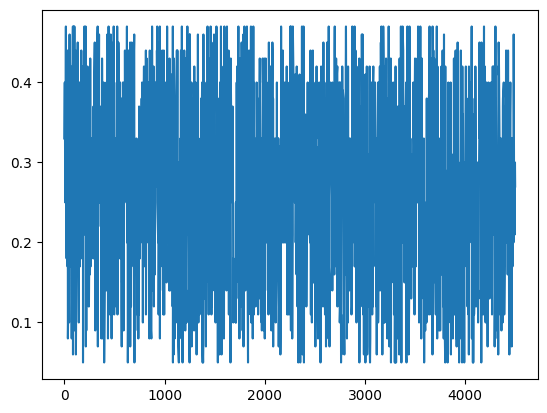

In [23]:
df_05.SN_ellip_dist.plot()

In [13]:
df.SN_ellip_dist.max()

np.float64(1.0)

In [24]:
cinco_por_galaxia = df.groupby('gal_objectId').head(5)
cinco_por_galaxia

,gal_objectId,gal_band,gal_visit,gal_detector,diff_sourceId,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4207,609788255411391107,z,2024120700337,0,612929079095591353,z,2024120900471,6,1.00,"[[224.30891, -33.865326, 6.9801407, 68.73816, ...","[[110.7932, -29.94855, -26.09108, -59.344803, ...","[[113.51572, -3.9167752, 33.07122, 128.08296, ...",simulated_data/fakes/609788255411391107_z_2024...
4250,609788873886679149,r,2024120300118,6,614437609048899658,r,2024120300100,0,0.50,"[[3.8641863, -20.829483, -18.070633, -17.20253...","[[11.748679, -32.46899, 0.23144123, -24.570013...","[[-7.884493, 11.639507, -18.302074, 7.3674817,...",simulated_data/fakes/609788873886679149_r_2024...
4378,609788736447730238,i,2024120300132,6,650018836115882078,i,2024112300243,1,1.00,"[[88.14358, -7.7519093, -75.71553, 51.676178, ...","[[41.66538, 19.687435, -118.33203, 25.975534, ...","[[46.4782, -27.439344, 42.616497, 25.700644, -...",simulated_data/fakes/609788736447730238_i_2024...
4401,611255759837084227,r,2024120300146,2,648365582944567320,r,2024112300214,4,0.50,"[[-31.276003, -40.35616, 32.78255, 26.583775, ...","[[-11.816378, 2.9092574, 20.763266, 13.437313,...","[[-19.459625, -43.265415, 12.019285, 13.146462...",simulated_data/fakes/611255759837084227_r_2024...


In [ ]:
# 4 arcseg

In [7]:
df = df.rename(columns={'gal_objectId': 'oid', 'diff_sourceId': 'measurement_id'})
df.head()

,oid,gal_band,gal_visit,gal_detector,measurement_id,diff_band,diff_visit,diff_detector,SN_ellip_dist,flux_Science_data,flux_Difference_data,flux_Template_data,original_path
0,611256378312376542,z,2024120800360,8,592913913020940296,z,2024111700354,4,0.33,"[[10.982742, -100.364624, -26.70795, 150.41075...","[[32.616245, -31.05905, -51.33175, 83.870514, ...","[[-21.633503, -69.30557, 24.623798, 66.54024, ...",simulated_data/fakes/611256378312376542_z_2024...
1,609780833707896898,g,2024112900266,0,650018217640591465,g,2024112600116,4,0.88,"[[210.51036, 194.16635, 226.60606, 208.87112, ...","[[4.6535196, -7.1084204, 15.935069, -5.0868855...","[[205.85684, 201.27477, 210.67099, 213.95801, ...",simulated_data/fakes/609780833707896898_g_2024...
2,611255691117605475,r,2024113000163,3,614437609048899879,r,2024112600305,1,0.74,"[[-24.263647, 23.363667, -8.025528, 55.17688, ...","[[-10.19281, 19.809084, -1.9615426, 28.060669,...","[[-14.070837, 3.5545833, -6.063985, 27.116209,...",simulated_data/fakes/611255691117605475_r_2024...
3,611255622398132035,i,2024120300157,8,648363383921311853,i,2024112300236,6,0.90,"[[60.298386, -91.77385, 44.987007, -35.799484,...","[[37.04548, -36.984486, 48.095524, -9.511111, ...","[[23.252905, -54.789364, -3.108515, -26.288372...",simulated_data/fakes/611255622398132035_i_2024...
4,609788117972430021,i,2024111900089,8,650018148921114792,i,2024112600128,5,0.57,"[[64.394684, 132.19717, -14.009651, 126.18045,...","[[-16.556696, 32.335075, -49.94117, 25.10089, ...","[[80.95138, 99.86209, 35.93152, 101.07956, 159...",simulated_data/fakes/609788117972430021_i_2024...


In [8]:
df.oid.nunique()

175

In [27]:
for row in df['flux_Science_data']:
    print(row.shape)

(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(

In [28]:
for row in df['flux_Difference_data']:
    print(row.shape)

(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(31, 31)
(

In [ ]:
## Para probar la calidad de las simulaciones
# Train --> Simuladas
# Val --> Simuladas
# Test --> Real

## Para probar (con porcentaje de peso para los datos)
# Train --> Real + Simuladas
# Val --> Real + Simuladas
# Test --> Real